Minimum points:
x = -1.0, f(x) = 4.0


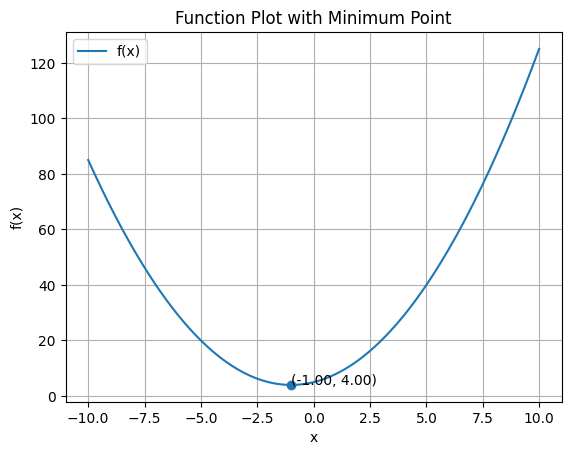

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

def find_minimum_symbolic(func_expr, var):
    # First derivative
    first_derivative = sp.diff(func_expr, var)

    # Solve f'(x) = 0
    critical_points = sp.solve(first_derivative, var)

    minima = []

    for point in critical_points:
        # Second derivative test
        second_derivative = sp.diff(first_derivative, var)
        value = second_derivative.subs(var, point)

        if value > 0:
            func_value = func_expr.subs(var, point)
            minima.append((float(point), float(func_value)))

    return minima


def plot_function(func_expr, var, minima, x_range=(-10, 10)):
    # Convert symbolic function to numerical
    f_lambdified = sp.lambdify(var, func_expr, 'numpy')

    x_vals = np.linspace(x_range[0], x_range[1], 400)
    y_vals = f_lambdified(x_vals)

    plt.figure()
    plt.plot(x_vals, y_vals, label="f(x)")

    # Plot minima points
    for x_min, y_min in minima:
        plt.scatter(x_min, y_min)
        plt.text(x_min, y_min, f"({x_min:.2f}, {y_min:.2f})")

    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title("Function Plot with Minimum Point")
    plt.legend()
    plt.grid()
    plt.show()


# Example usage
x = sp.symbols('x')
f = x**2 + 2*x + 5

min_points = find_minimum_symbolic(f, x)

print("Minimum points:")
for point, value in min_points:
    print(f"x = {point}, f(x) = {value}")

# Plot the function
plot_function(f, x, min_points)

Minimum at x = -2.499950441658072, f(x) = 3.750000002456029


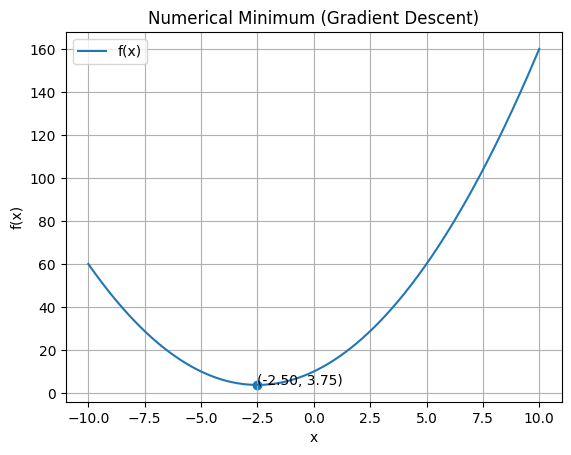

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def numerical_derivative(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

def find_minimum_numerical(f, x0, learning_rate=0.01, tol=1e-6, max_iter=1000):
    x = x0

    for _ in range(max_iter):
        grad = numerical_derivative(f, x)
        x_new = x - learning_rate * grad

        if abs(x_new - x) < tol:
            break

        x = x_new

    return x, f(x)


def plot_numerical(f, min_x, x_range=(-10, 10)):
    x_vals = np.linspace(x_range[0], x_range[1], 400)
    y_vals = [f(x) for x in x_vals]

    plt.figure()
    plt.plot(x_vals, y_vals, label="f(x)")

    # Mark minimum
    plt.scatter(min_x, f(min_x))
    plt.text(min_x, f(min_x), f"({min_x:.2f}, {f(min_x):.2f})")

    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title("Numerical Minimum (Gradient Descent)")
    plt.legend()
    plt.grid()
    plt.show()


# Example usage
f = lambda x: x**2 + 5*x + 10

min_x, min_val = find_minimum_numerical(f, x0=0)

print(f"Minimum at x = {min_x}, f(x) = {min_val}")

plot_numerical(f, min_x)